In [60]:
import pandas as pd
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from datetime import datetime
from sklearn.cluster import KMeans

sns.set_theme(style="whitegrid")

In [61]:
file_pattern = "./data/2025*-citibike-tripdata_*.csv"
file_list = glob.glob(file_pattern)

df_summer = pd.concat(
    (pd.read_csv(file, dtype={ "start_station_id": str, "end_station_id": str }) for file in file_list), 
    ignore_index = True
)

df_summer.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,6532F46EF12DCA8C,electric_bike,2025-06-12 15:08:06.700,2025-06-12 15:11:20.652,Mercer St & Bleecker St,5679.05,E 1 St & Bowery,5636.13,40.727064,-73.996621,40.724861,-73.992131,member
1,DE5D64BE54489439,electric_bike,2025-06-12 13:05:20.309,2025-06-12 13:22:18.812,45 Rd & 11 St,6319.01,43 Ave & 42 St,6251.06,40.747086,-73.949772,40.745347,-73.921942,member
2,A19F721536473DA2,classic_bike,2025-06-13 18:03:51.268,2025-06-13 18:11:24.704,95 St & 35 Ave,6465.04,84 St & Roosevelt Ave,6323.04,40.753010,-73.872660,40.747970,-73.882040,member
3,5695831104F572BB,classic_bike,2025-06-11 17:01:40.807,2025-06-11 17:24:19.780,4 Ave & 17 St,3739.06,Willoughby St & Ashland Pl,4587.02,40.665507,-73.993037,40.691780,-73.978770,member
4,08F1301EED21DFC7,electric_bike,2025-06-06 18:43:26.907,2025-06-06 18:48:48.209,Mercer St & Bleecker St,5679.05,St Marks Pl & 2 Ave,5669.10,40.727064,-73.996621,40.728419,-73.987140,member


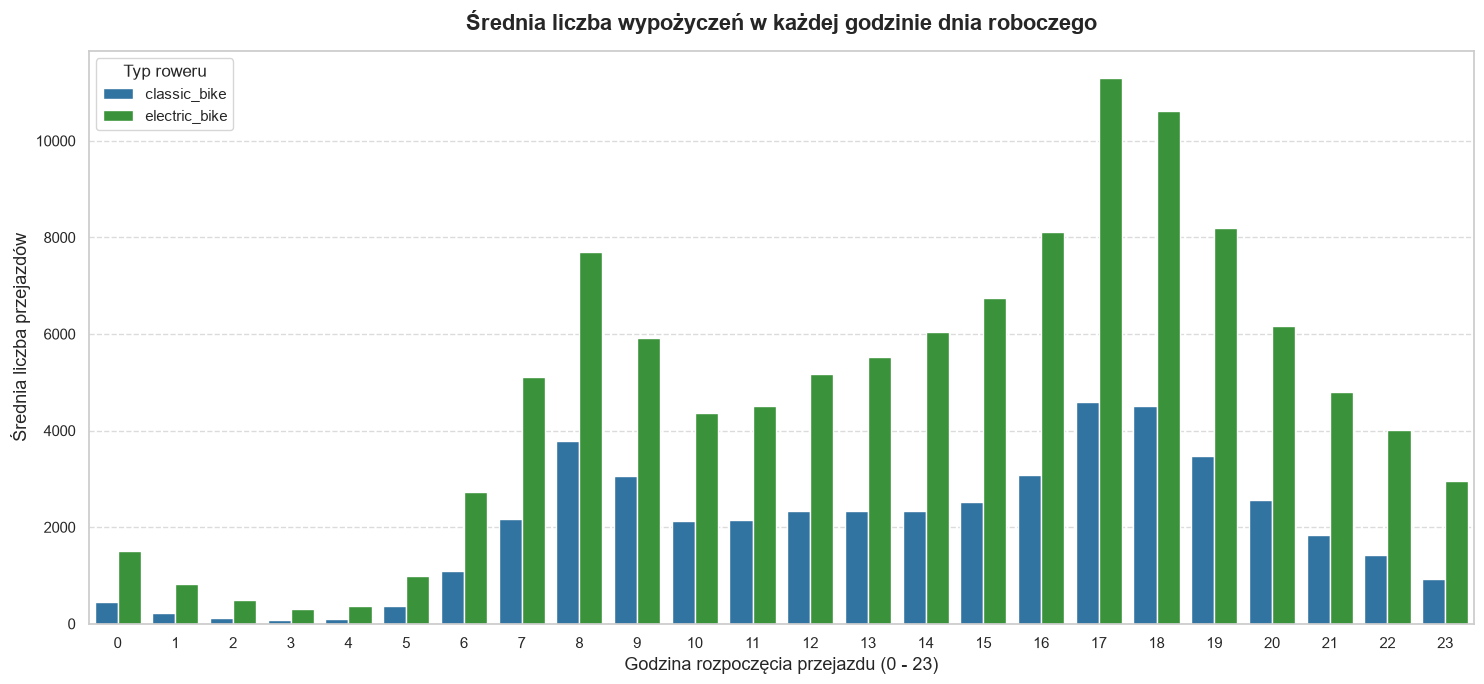

In [62]:
df_summer["started_at"] = pd.to_datetime(df_summer["started_at"])

df_weekdays = df_summer[df_summer["started_at"].dt.dayofweek < 5].copy()
df_weekdays["hour"] = df_weekdays["started_at"].dt.hour

unique_weekdays = df_weekdays["started_at"].dt.date.nunique()

hourly_stats = df_weekdays.groupby(["hour", "rideable_type"]).size().reset_index(name="total_rides")
hourly_stats["avg_rides_per_day"] = hourly_stats["total_rides"] / unique_weekdays

plt.figure(figsize=(15, 7))

ax = sns.barplot(
    data=hourly_stats,
    x="hour",
    y="avg_rides_per_day",
    hue="rideable_type",
    palette={"electric_bike": "#2CA02C", "classic_bike": "#1F77B4"}
)

plt.title("Średnia liczba wypożyczeń w każdej godzinie dnia roboczego", fontsize=16, fontweight="bold", pad=15)

plt.xlabel("Godzina rozpoczęcia przejazdu (0 - 23)", fontsize=13)
plt.ylabel("Średnia liczba przejazdów", fontsize=13)

plt.legend(title="Typ roweru", loc="upper left", fontsize=11, title_fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

📊 RAPORT: STRUKTURA PORANNEGO RUCHU (06:00 - 09:00)
Całkowita liczba przejazdów:      1,491,854
Przejazdy z metą na Manhattanie:  968,538 (64.9%)
  ↳ w tym z innych dzielnic:      141,234 (14.6% wszystkich met na Manhattanie)


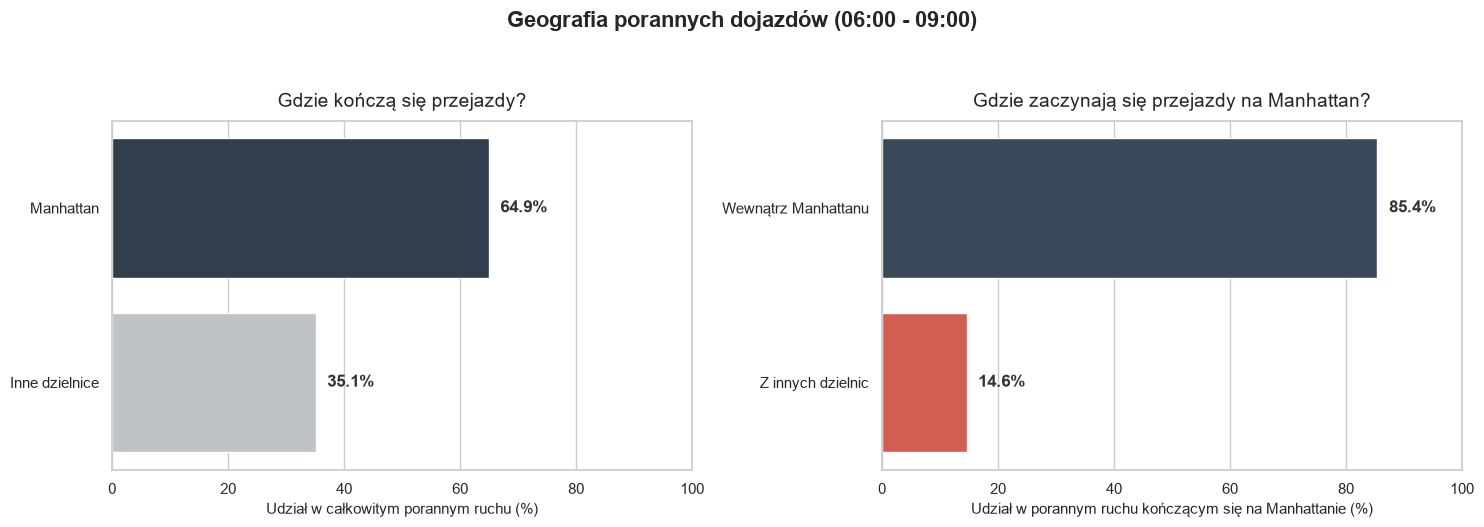

In [67]:
def identify_manhattan(df, lat_col, lng_col):
    in_lat = df[lat_col].between(40.700, 40.880)
    in_lng = df[lng_col].between(-74.025, -73.910)
    
    not_jersey = ~((df[lng_col] < -74.005) & (df[lat_col] < 40.750))
    not_brooklyn_queens = ~((df[lng_col] > -73.970) & (df[lat_col] < 40.740))
    
    return in_lat & in_lng & not_jersey & not_brooklyn_queens

df_morning = df_weekdays[(df_weekdays["started_at"].dt.hour >= 6) & (df_weekdays["started_at"].dt.hour < 9)].copy()

df_morning["start_in_manhattan"] = identify_manhattan(df_morning, "start_lat", "start_lng")
df_morning["end_in_manhattan"] = identify_manhattan(df_morning, "end_lat", "end_lng")

total_rides = len(df_morning)

ends_in_manhattan = df_morning["end_in_manhattan"].sum()
ends_outside = total_rides - ends_in_manhattan

commuters_count = len(df_morning[(df_morning["end_in_manhattan"]) & (~df_morning["start_in_manhattan"])])
internal_manhattan_commuters_count = ends_in_manhattan - commuters_count

print("📊 RAPORT: STRUKTURA PORANNEGO RUCHU (06:00 - 09:00)")
print("=" * 55)
print(f"Całkowita liczba przejazdów:      {total_rides:,}")
print(f"Przejazdy z metą na Manhattanie:  {ends_in_manhattan:,} ({(ends_in_manhattan/total_rides)*100:.1f}%)")
print(f"  ↳ w tym z innych dzielnic:      {commuters_count:,} ({(commuters_count/ends_in_manhattan)*100:.1f}% wszystkich met na Manhattanie)")
print("=" * 55)

df_dest = pd.DataFrame({
    "Kategoria": ["Manhattan", "Inne dzielnice"],
    "Procent": [(ends_in_manhattan/total_rides)*100, (ends_outside/total_rides)*100]
})

df_origin = pd.DataFrame({
    "Kategoria": ["Wewnątrz Manhattanu", "Z innych dzielnic"],
    "Procent": [(internal_manhattan_commuters_count/ends_in_manhattan)*100, (commuters_count/ends_in_manhattan)*100]
})

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Geografia porannych dojazdów (06:00 - 09:00)", fontsize=16, fontweight="bold", y=1.05)

sns.barplot(x="Procent", y="Kategoria", data=df_dest, ax=axes[0], 
            hue="Kategoria", legend=False, palette=["#2C3E50", "#BDC3C7"])

axes[0].set_title("Gdzie kończą się przejazdy?", fontsize=14, pad=10)
axes[0].set_xlabel("Udział w całkowitym porannym ruchu (%)", fontsize=11)
axes[0].set_ylabel("")
axes[0].set_xlim(0, 100)

for p in axes[0].patches:
    width = p.get_width()
    axes[0].text(width + 2, p.get_y() + p.get_height()/2., f"{width:.1f}%", 
                 ha="left", va="center", fontsize=12, fontweight="bold", color="#333333")

sns.barplot(x="Procent", y="Kategoria", data=df_origin, ax=axes[1], 
            hue="Kategoria", legend=False, palette=["#34495E", "#E74C3C"])

axes[1].set_title("Gdzie zaczynają się przejazdy na Manhattan?", fontsize=14, pad=10)
axes[1].set_xlabel("Udział w porannym ruchu kończącym się na Manhattanie (%)", fontsize=11)
axes[1].set_ylabel("")
axes[1].set_xlim(0, 100)

for p in axes[1].patches:
    width = p.get_width()
    axes[1].text(width + 2, p.get_y() + p.get_height()/2., f"{width:.1f}%", 
                 ha="left", va="center", fontsize=12, fontweight="bold", color="#333333")

plt.tight_layout()
plt.show()

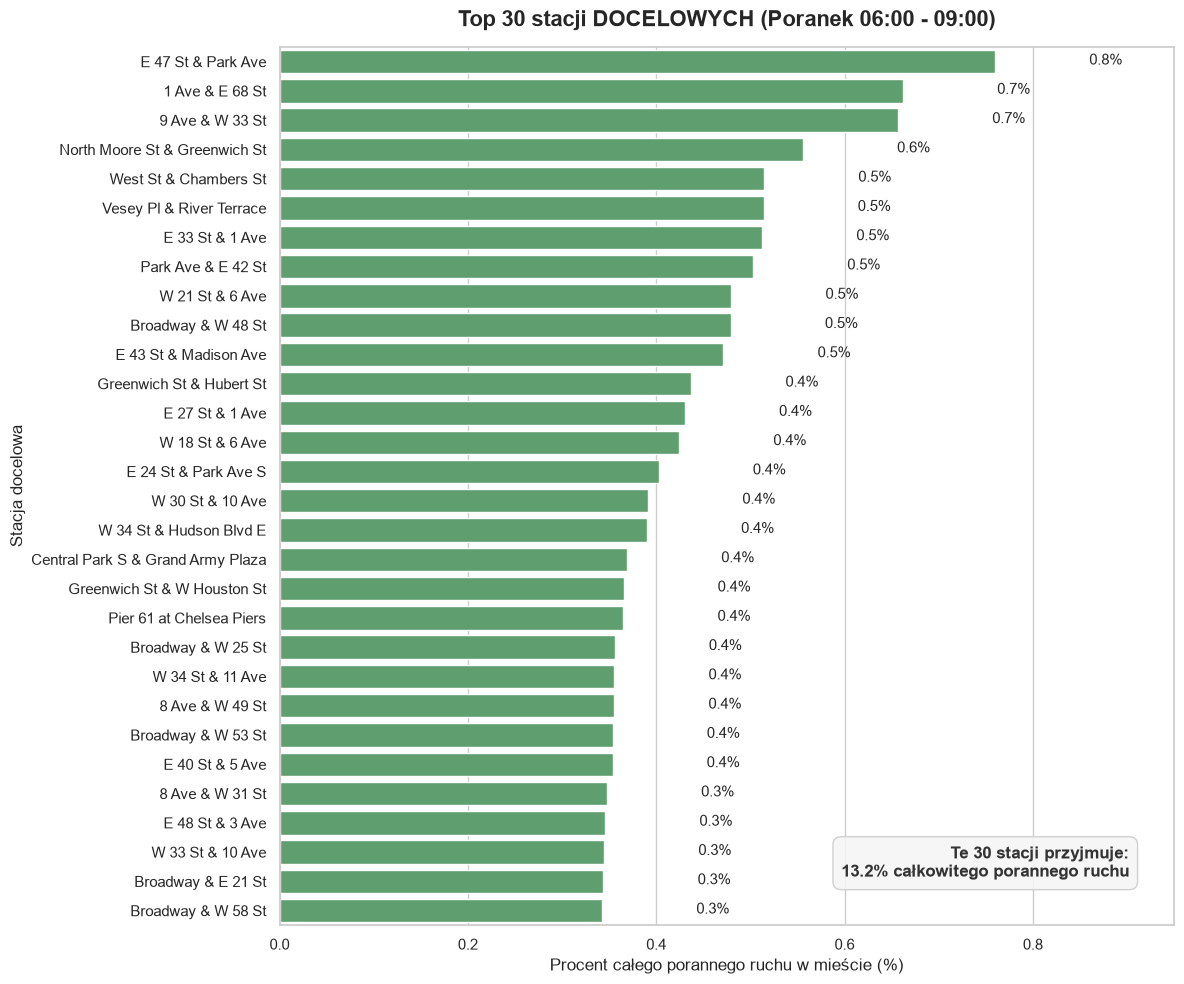

In [66]:
top_end_stations_count = 30

df_morning_early = df_weekdays[(df_weekdays["started_at"].dt.hour >= 6) & (df_weekdays["started_at"].dt.hour < 9)]

total_morning_rides = len(df_morning_early)

top_dests = df_morning_early["end_station_name"].value_counts().nlargest(top_end_stations_count).reset_index()
top_dests.columns = ["station_name", "Count"]

top_dests["Percentage"] = (top_dests["Count"] / total_morning_rides) * 100
total_dest_pct = top_dests["Percentage"].sum()

plt.figure(figsize=(12, 10))

ax = sns.barplot(x="Percentage", y="station_name", data=top_dests, color="#55A868")

plt.title(f"Top {top_end_stations_count} stacji DOCELOWYCH (Poranek 06:00 - 09:00)", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Procent całego porannego ruchu w mieście (%)", fontsize=12)
plt.ylabel("Stacja docelowa", fontsize=12)
plt.xlim(0, top_dests["Percentage"].max() * 1.25)

for p in ax.patches:
    width = p.get_width()
    plt.text(width + 0.1, p.get_y() + p.get_height() / 2. + 0.1, f"{width:.1f}%", ha="left", fontsize=11)

plt.text(0.95, 0.05, f"Te {top_end_stations_count} stacji przyjmuje:\n{total_dest_pct:.1f}% całkowitego porannego ruchu", 
         transform=ax.transAxes, fontsize=12, fontweight="bold", color="#333333",
         ha="right", va="bottom", bbox=dict(boxstyle="round,pad=0.5", facecolor="#F5F5F5", alpha=0.9, edgecolor="#CCCCCC"))

plt.tight_layout()
plt.show()

In [68]:
station_locations = df_morning_early.groupby("end_station_name").agg({
    "end_lat": "mean",
    "end_lng": "mean"
}).reset_index()

cluster_data = pd.merge(top_dests, station_locations, left_on="station_name", right_on="end_station_name")
cluster_data = cluster_data.dropna(subset=["end_lat", "end_lng"])

X = cluster_data[["end_lat", "end_lng"]]
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
cluster_data["Cluster_ID"] = kmeans.fit_predict(X)

map_center = [cluster_data["end_lat"].mean(), cluster_data["end_lng"].mean()]
nyc_cluster_map = folium.Map(location=map_center, zoom_start=13, tiles="cartodbpositron")

cluster_colors = {
    0: "red",
    1: "blue",
    2: "green",
    3: "purple",
    4: "orange"
}

for index, row in cluster_data.iterrows():
    cluster_num = row["Cluster_ID"]
    color = cluster_colors[cluster_num]
    
    popup_text = f"""
    <div style="font-family: Arial; font-size: 13px;">
        <b>{row['station_name']}</b><br>
        Strefa logistyczna: <b>{cluster_num + 1}</b><br>
        Przejazdy: {row['Count']} ({row['Percentage']:.1f}% z Top 30)
    </div>
    """
    
    folium.Marker(
        location=[row["end_lat"], row["end_lng"]],
        tooltip=f"Strefa {cluster_num + 1}: {row['station_name']}",
        popup=folium.Popup(popup_text, max_width=250),
        icon=folium.Icon(color=color, icon="star")
    ).add_to(nyc_cluster_map)

nyc_cluster_map